In [1]:
!pip install seaborn plotly
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [2]:
appointments = pd.read_csv(r"D:\Python Project\Hospital Management Reports\CSV Files\appointments.csv")
billing      = pd.read_csv(r"D:\Python Project\Hospital Management Reports\CSV Files\billing.csv")
doctors      = pd.read_csv(r"D:\Python Project\Hospital Management Reports\CSV Files\doctors.csv")
patients     = pd.read_csv(r"D:\Python Project\Hospital Management Reports\CSV Files\patients.csv")
treatments   = pd.read_csv(r"D:\Python Project\Hospital Management Reports\CSV Files\treatments.csv")

In [23]:
doctors

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email,Full_Name
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com,David Taylor
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com,Jane Davis
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com,Jane Smith
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com,David Jones
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com,Sarah Taylor
5,D006,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com,Alex Davis
6,D007,Robert,Davis,Oncology,8217493115,26,Westside Clinic,dr.robert.davis@hospital.com,Robert Davis
7,D008,Linda,Brown,Dermatology,9069162601,5,Westside Clinic,dr.linda.brown@hospital.com,Linda Brown
8,D009,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com,Sarah Smith
9,D010,Linda,Wilson,Oncology,6176383634,21,Eastside Clinic,dr.linda.wilson@hospital.com,Linda Wilson


#### Total Revenue

In [37]:
Total_Revenue = billing['amount'].sum()
print(round(Total_Revenue, 2))

551249.85


#### Total Patients

In [53]:
Total_Patient = appointments['patient_id'].nunique()
Total_Patient

48

#### Total Doctors

In [33]:
Total_Doctors = doctors['doctor_id'].nunique()
Total_Doctors

10

##### Total Appointment

In [39]:
Total_Appointments = appointments['appointment_id'].nunique()
print(Total_Appointments)

200


#### Avg Treatment Cost

In [49]:
Avg_Treatment_Cost = treatments['cost'].mean()
print(round(Avg_Treatment_Cost,2))

2756.25


#### Avg Bill Amount

In [46]:
Avg_Bill_Amount = billing['amount'].mean()
print(round(Avg_Bill_Amount, 2))

2756.25


#### Appointments by Month Using Matplotlib Library

In [85]:
appointments['appointment_date'] =pd.to_datetime(appointments['appointment_date'])
appointments['Month'] = appointments['appointment_date'].dt.strftime('%b')
appointments['Month_No'] = appointments['appointment_date'].dt.month

monthly_appointments =(
    appointments.groupby(['Month_No','Month'])
    .size()
    .reset_index(name='Appointments')
)
print(monthly_appointments[['Month', 'Appointments']])

   Month  Appointments
0    Jan            20
1    Feb            14
2    Mar            19
3    Apr            25
4    May            19
5    Jun            18
6    Jul            16
7    Aug            15
8    Sep            11
9    Oct            14
10   Nov            17
11   Dec            12


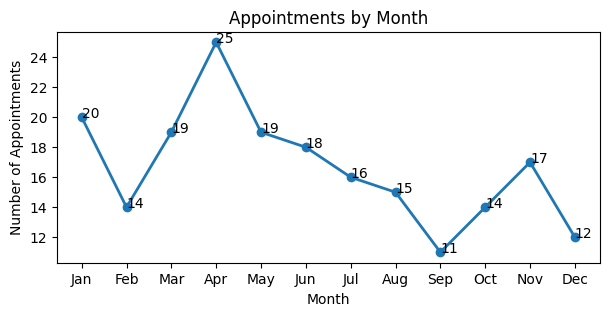

In [44]:
plt.figure(figsize =(7,3))
plt.plot(
    monthly_appointments['Month'],
    monthly_appointments['Appointments'],
    marker = 'o',
    linewidth =2
)
for x,y in zip(monthly_appointments['Month'],
               monthly_appointments['Appointments']):
    plt.text(x,y, str(y))
    
plt.title("Appointments by Month")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.show()

#### Appointments by Hospital Branch Using Matplotlib Library

In [58]:
merged_df = appointments.merge(
    doctors[['doctor_id', 'hospital_branch']],
    on = 'doctor_id',
    how = 'left'
    )
hospital_branch =(
    merged_df.groupby('hospital_branch')
    .size()
    .reset_index(name='Total_Appointments')
)
print(hospital_branch)

    hospital_branch  Total_Appointments
0  Central Hospital                  84
1   Eastside Clinic                  62
2   Westside Clinic                  54


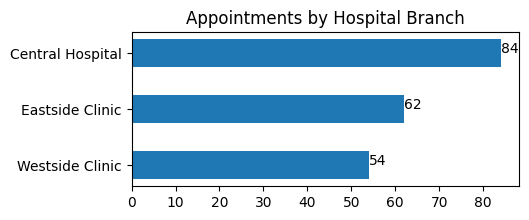

In [62]:
hospital_branch = hospital_branch.sort_values(
    by= 'Total_Appointments',
    ascending = True
)
plt.figure(figsize = (5,2))
plt.barh(hospital_branch['hospital_branch'],
         hospital_branch['Total_Appointments'],
         height = 0.5,
        )
for x,y in zip(hospital_branch['Total_Appointments'],
               hospital_branch['hospital_branch']):
    plt.text(x,y, str(x))
    plt.title('Appointments by Hospital Branch')
plt.show()

#### Appointments by Status Using Matplotlib Library

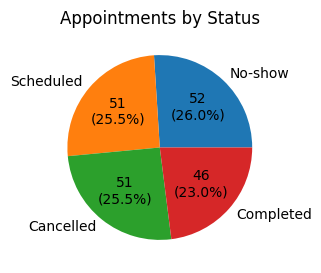

In [84]:
status_counts = appointments['status'].value_counts()

plt.figure(figsize = (4,3))
plt.pie(
    status_counts,
    labels = status_counts.index,
    autopct = lambda p: f'{int(round(p/100 * status_counts.sum()))}\n({p:.1f}%)'
)

plt.title('Appointments by Status')
plt.show()

#### Total Bill by Payment Status Using Matplotlib Library

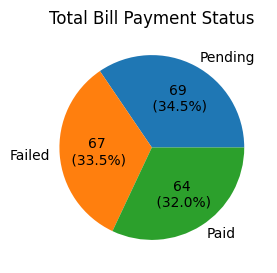

In [23]:
payment_status = billing['payment_status'].value_counts()
plt.figure(figsize = (4,3))
plt.pie(
    payment_status,
    labels = payment_status.index,
    autopct = lambda p: f'{int(round(p/100* payment_status.sum()))}\n ({p:.1f}%)'
)
plt.title('Total Bill Payment Status')
plt.show()

#### Top 5 Avg Revenue by Per Patient Using Matplotlib Library

In [64]:
patients['Full_Name'] = patients['first_name'] + ' ' + patients['last_name']

revenue_by_patient =(
    billing.groupby('patient_id')['amount']
    .mean()
    .reset_index(name='Avg_Revenue')
    .sort_values('Avg_Revenue', ascending =False)
    .head(5)
)

revenue_by_patient = revenue_by_patient.merge(
    patients[['patient_id', 'Full_Name']],
    on = 'patient_id',
    how= 'left'
    )

revenue_by_patient['Avg_Revenue'] = revenue_by_patient['Avg_Revenue'].round(2)

print(revenue_by_patient[['Full_Name', 'Avg_Revenue']])

       Full_Name  Avg_Revenue
0  Robert Taylor      4662.05
1    Alex Taylor      4412.06
2    Laura Jones      3968.44
3  Robert Wilson      3902.63
4    Emily Jones      3864.44


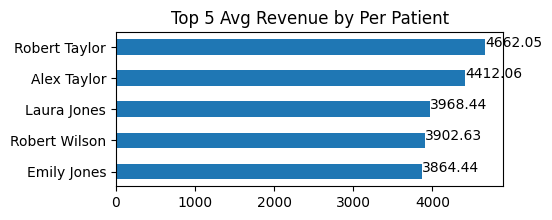

In [65]:
revenue_by_patient = revenue_by_patient.sort_values(
    by= 'Avg_Revenue',
    ascending = True
)

plt.figure(figsize = (5,2))
plt.barh(revenue_by_patient['Full_Name'],
         revenue_by_patient['Avg_Revenue'],
         height = 0.5
        )
for x,y in zip(revenue_by_patient['Full_Name'],
               revenue_by_patient['Avg_Revenue']):
    plt.text(y,x, str(y))
    plt.title('Top 5 Avg Revenue by Per Patient')
plt.show()
    

#### Total Patients by Insurance Provider Using Matplotlib Library

In [66]:
insurance_provider = (
    patients.groupby('insurance_provider')
    .size()
    .reset_index(name = 'Total_Patients')
)
print(insurance_provider)

  insurance_provider  Total_Patients
0        HealthIndia               6
1       MedCare Plus              18
2        PulseSecure              10
3       WellnessCorp              16


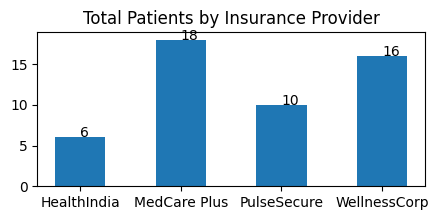

In [67]:
plt.figure(figsize = (5,2))
plt.bar(insurance_provider['insurance_provider'],
        insurance_provider['Total_Patients'],
        width = 0.5
       )
for x,y in zip(insurance_provider['insurance_provider'],
               insurance_provider['Total_Patients']):
    plt.text(x,y, str(y))
    plt.title('Total Patients by Insurance Provider')
plt.show()
    

#### Patients Registered by Month Using Matplotlib Library

In [68]:
patients['registration_date'] = pd.to_datetime(patients['registration_date'])
patients['Month'] = patients['registration_date'].dt.strftime('%b')
patients['Month_No'] = patients['registration_date'].dt.month

monthly_registered = (
    patients.groupby(['Month_No','Month'])
    .size()
    .reset_index(name = 'Total_Patients')
)
print(monthly_registered[['Month', 'Total_Patients']])

   Month  Total_Patients
0    Jan               4
1    Feb               1
2    Mar               3
3    Apr               5
4    May               5
5    Jun               6
6    Jul               5
7    Aug               3
8    Sep              10
9    Oct               4
10   Dec               4


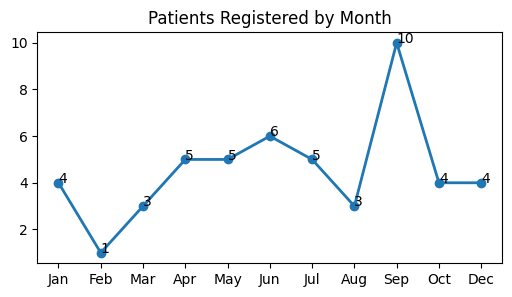

In [69]:
plt.figure(figsize = (6,3))
plt.plot(monthly_registered['Month'],
         monthly_registered['Total_Patients'],
         marker ='o',
         linewidth ='2'
        )
for x,y in zip(monthly_registered['Month'],
               monthly_registered['Total_Patients']):
    plt.text(x,y, str(y))
    plt.title('Patients Registered by Month')
plt.show()    
    

#### Total Patients by Gender Using Matplotlib Library

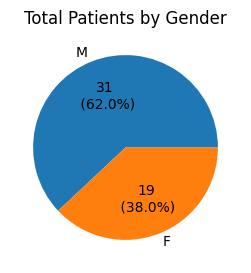

In [71]:
gender_count = patients['gender'].value_counts()

plt.figure(figsize = (4,3))
plt.pie(gender_count,
        labels=gender_count.index,
        autopct = lambda p: f'{int(round(p/100 * gender_count.sum()))}\n ({p:.1f}%)'
       )
plt.title('Total Patients by Gender')
plt.show()

#### Total Patients by Reason_For_Visit Using Matplotlib Library

In [72]:
merged_df = patients.merge(
    appointments[['patient_id', 'reason_for_visit']],
    on = 'patient_id',
    how = 'left'
)

patient_visit = (
                 merged_df.groupby('reason_for_visit')
                 .size()
                 .reset_index(name = 'Total_Patients')
                )
print(patient_visit)      

  reason_for_visit  Total_Patients
0          Checkup              45
1     Consultation              43
2        Emergency              29
3        Follow-up              41
4          Therapy              42


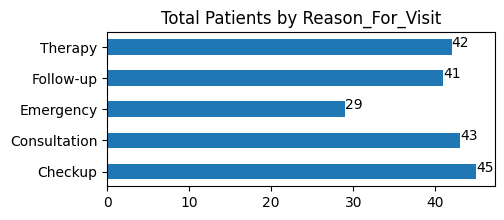

In [73]:
plt.figure(figsize = (5,2))
plt.barh(patient_visit['reason_for_visit'],
         patient_visit['Total_Patients'],
         height = 0.5
        )
for x,y in zip(patient_visit['reason_for_visit'],
         patient_visit['Total_Patients']):
    plt.text(y,x, str(y))
    plt.title('Total Patients by Reason_For_Visit')
plt.show()    

#### Patients by Age Group Using Plotly and Pandas Library

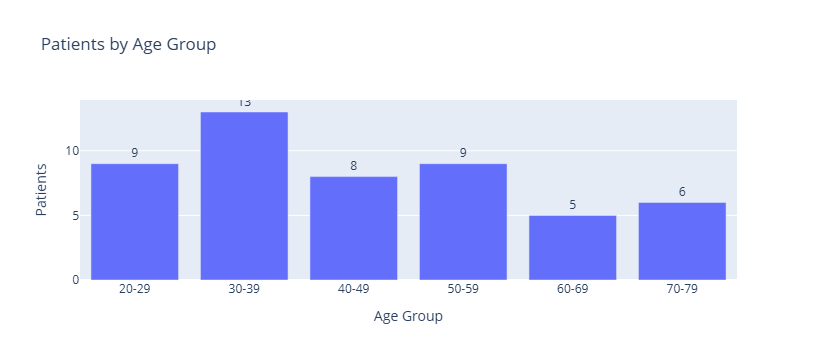

In [125]:
# Convert DOB to datetime
patients['date_of_birth'] = pd.to_datetime(patients['date_of_birth'])
# Calculate age
today = pd.Timestamp.today()
patients['Age'] = ((today - patients['date_of_birth']).dt.days / 365.25).astype(int)
# Create age groups
bins = [0, 9, 19, 29, 39, 49, 59, 69, 79, 89]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49',
          '50-59', '60-69', '70-79', '80-89']

patients['Age Group'] = pd.cut(patients['Age'], bins=bins, labels=labels)
# Count patients
age_group_count = (
    patients.groupby('Age Group', observed=False)['patient_id']
      .count()
      .reset_index(name='Patients')
)
# Remove empty groups
age_group_count = age_group_count[age_group_count['Patients'] > 0]
# Plot
fig = px.bar(
    age_group_count,
    x='Age Group',
    y='Patients',
    text='Patients',
    title='Patients by Age Group'
)
fig.update_traces(textposition='outside')
fig.show()

#### Total Appointments by Patient Using Plotly Library

In [74]:
merged_df = appointments.merge(
    patients[['patient_id', 'Full_Name']],
    on = 'patient_id',
    how = 'left'
)

patient_appointment = (
    merged_df.groupby('Full_Name')
    .size()
    .reset_index(name = 'Appointment_count')
    .sort_values('Appointment_count', ascending = False)
    .head(5)
    )

print(patient_appointment)

          Full_Name  Appointment_count
29   Michael Taylor                 16
8      David Wilson                 15
30   Michael Wilson                 14
20      Laura Davis                 14
33  Robert Williams                  9


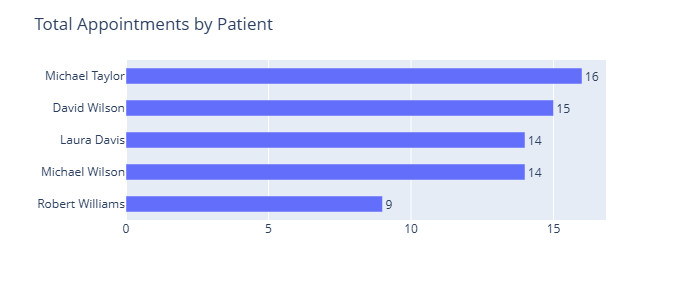

In [76]:
patient_appointment =  patient_appointment.sort_values(
    by= 'Appointment_count',
    ascending = True
)
    
fig =px.bar(
    patient_appointment,
    x = 'Appointment_count',
    y = 'Full_Name',
    orientation = 'h',
    text = 'Appointment_count',
)

fig.update_traces(textposition = 'outside')

fig.update_layout(
    xaxis_title = '',
    yaxis_title = '',
    width = 600,
    height = 300,
    bargap = 0.5,
    title = 'Total Appointments by Patient'
)
fig.show()

#### Appointment by Doctor Using Plotly Library

In [21]:
doctors['Full_Name'] = doctors['first_name'] + ' ' + doctors['last_name']

merged_df = appointments.merge(
    doctors[['doctor_id', 'Full_Name']],
    on = 'doctor_id',
    how = 'left'
)

dr_appointment = (
    merged_df.groupby('Full_Name')
    .size()
    .reset_index(name ='Total_appointment')
    .sort_values('Total_appointment', ascending = False)
)

print(dr_appointment)

      Full_Name  Total_appointment
9  Sarah Taylor                 29
2  David Taylor                 25
0    Alex Davis                 24
4    Jane Smith                 22
3    Jane Davis                 21
6  Linda Wilson                 19
8   Sarah Smith                 17
5   Linda Brown                 16
1   David Jones                 14
7  Robert Davis                 13


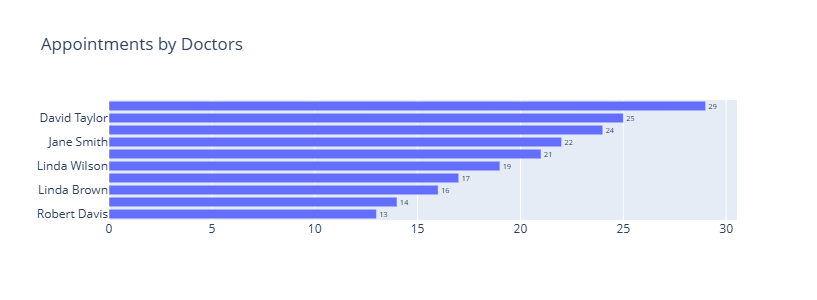

In [22]:
dr_appointment = dr_appointment.sort_values(
    by = 'Total_appointment',
    ascending = True
)

fig = px.bar(
    dr_appointment,
    x= 'Total_appointment',
    y= 'Full_Name',
    orientation = 'h',
    text = 'Total_appointment',
    title = 'Appointments by Doctors'
)

fig.update_traces(textposition = 'outside')

fig.update_layout(
    width = 600,
    height = 300,
    xaxis_title = '',
    yaxis_title = ''
)

fig.show()

#### Avg Treatment Cost by Treatment Type Using Plotly Library

In [52]:
treatment_cost =(
    treatments.groupby('treatment_type')['cost']
    .mean()
    .reset_index(name = 'Avg_Treatment_Cost')
    .sort_values('Avg_Treatment_Cost', ascending = False)
)

treatment_cost['Avg_Treatment_Cost'] = treatment_cost['Avg_Treatment_Cost'].round(1)

print(treatment_cost)

  treatment_type  Avg_Treatment_Cost
2            MRI              3224.9
3  Physiotherapy              2761.6
4          X-Ray              2698.9
0   Chemotherapy              2629.7
1            ECG              2532.2


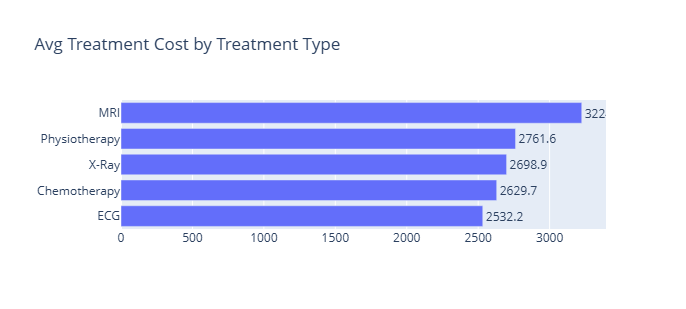

In [56]:
treatment_cost = treatment_cost.sort_values(
by = 'Avg_Treatment_Cost',
ascending = True
)

fig = px.bar(
    treatment_cost,
    x = 'Avg_Treatment_Cost',
    y = 'treatment_type',
    orientation = 'h',
    text = 'Avg_Treatment_Cost',
    title = 'Avg Treatment Cost by Treatment Type'
)

fig.update_traces(textposition = 'outside')

fig.update_layout(
    width = 750,
    height = 300,
    xaxis_title = '',
    yaxis_title = ''
)

fig.show()

#### Payment Method Most Preferred by Patients Using Plotly Library

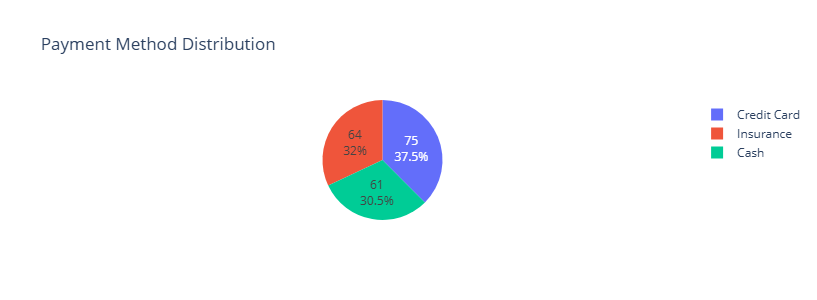

In [28]:
payment_method = billing['payment_method'].value_counts()
fig = px.pie(
    values = payment_method.values,
    names = payment_method.index,
    title = 'Payment Method Distribution'
)

fig.update_traces(
    textposition = 'inside',
    textinfo = 'value+percent'
)

fig.update_layout(
    width = 500,
    height = 300
)

fig.show()

#### Payment Method Most Preferred by Patients Using Plotly.graph_object

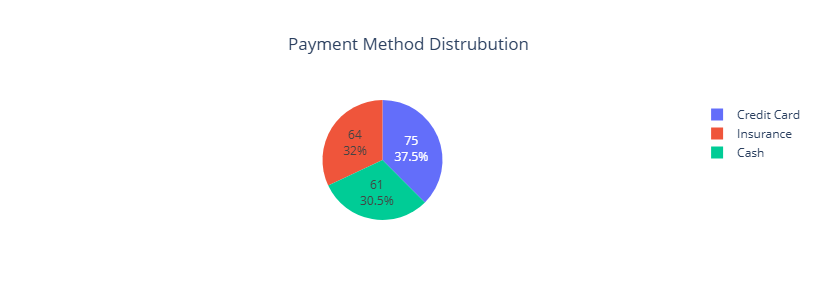

In [5]:
payment_method = billing['payment_method'].value_counts()

fig = go.Figure(
    go.Pie(
    values = payment_method.values,
    labels = payment_method.index,
    textinfo = 'value+percent'
)
)
fig.update_layout(
    # center the title
    title = {
        'text': 'Payment Method Distrubution',
        'x': 0.5
    },
    width = 500,
    height = 300
)
fig.show()

#### Total Treatments by Treatment Type Using Seaborn Library

In [10]:
Total_Treatment_Type = (
    treatments.groupby('treatment_type')['treatment_id']
    .size()
    .reset_index(name = 'Treatment_counts')
)
print(Total_Treatment_Type)

  treatment_type  Treatment_counts
0   Chemotherapy                49
1            ECG                38
2            MRI                36
3  Physiotherapy                36
4          X-Ray                41


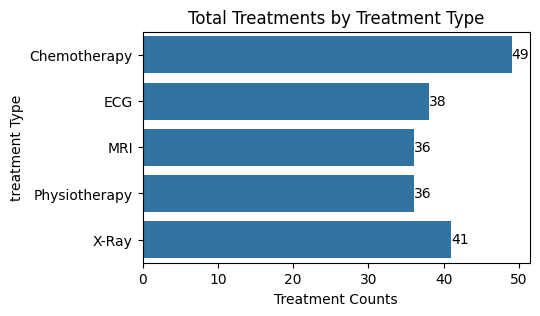

In [18]:
plt.figure(figsize = (5,3))
ax = sns.barplot(
    data = Total_Treatment_Type,
    x= 'Treatment_counts',
    y= 'treatment_type'
)
plt.title('Total Treatments by Treatment Type')
plt.xlabel('Treatment Counts')
plt.ylabel('treatment Type')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

#### Total Revenue by Doctor Using Seaborn Library

In [37]:
merged_df  = billing.merge(
    treatments[['treatment_id', 'appointment_id']],
    on = 'treatment_id'
)
merged_df = merged_df.merge(
    appointments[['appointment_id', 'doctor_id']],
    on = 'appointment_id'
)
merged_df = merged_df.merge(
    doctors[['doctor_id', 'Full_Name']],
    on = 'doctor_id'
)
doctor_revenue = (
    merged_df.groupby('Full_Name')['amount']
    .sum()
    .reset_index(name = 'Total_Revenue')
    .sort_values(by = 'Total_Revenue', ascending = False)
)
doctor_revenue['Total_Revenue'] = doctor_revenue['Total_Revenue'].round(0) 

print(doctor_revenue)

      Full_Name  Total_Revenue
9  Sarah Taylor        82696.0
0    Alex Davis        69586.0
2  David Taylor        66585.0
3    Jane Davis        59803.0
5   Linda Brown        53427.0
4    Jane Smith        52791.0
6  Linda Wilson        49436.0
7  Robert Davis        40166.0
1   David Jones        39316.0
8   Sarah Smith        37441.0


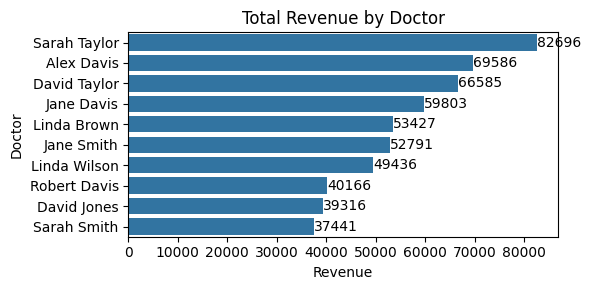

In [34]:
plt.figure(figsize = (6,3))

ax = sns.barplot(
    data = doctor_revenue,
    x= 'amount',
    y= 'Full_Name'
)

plt.title('Total Revenue by Doctor')
plt.xlabel('Revenue')
plt.ylabel('Doctor')

for container in ax.containers:
    ax.bar_label(container, fmt= '%.0f')
plt.tight_layout()
plt.show()

#### Total Revenue by Specialization Using Seaborn Library

In [38]:
merged_df  = billing.merge(
    treatments[['treatment_id', 'appointment_id']],
    on = 'treatment_id'
)
merged_df = merged_df.merge(
    appointments[['appointment_id', 'doctor_id']],
    on = 'appointment_id'
)
merged_df = merged_df.merge(
    doctors[['doctor_id', 'specialization']],
    on = 'doctor_id'
)
doctor_revenue = (
    merged_df.groupby('specialization')['amount']
    .sum()
    .reset_index(name = 'Total_Revenue')
    .sort_values(by = 'Total_Revenue', ascending = False)
)
doctor_revenue['Total_Revenue'] = doctor_revenue['Total_Revenue'].round(0) 

print(doctor_revenue)

  specialization  Total_Revenue
2     Pediatrics       258938.0
0    Dermatology       202709.0
1       Oncology        89603.0


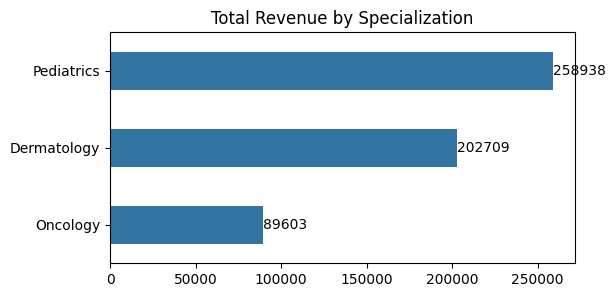

In [45]:
plt.figure(figsize = (6,3))
fig = sns.barplot(
    doctor_revenue,
    x= 'Total_Revenue',
    y= 'specialization',
    width = 0.5
)
plt.title('Total Revenue by Specialization')
plt.xlabel('')
plt.ylabel('')

for container in fig.containers:
    fig.bar_label(container)
plt.show()    